In [1]:
!pip install pandas numpy matplotlib statsmodels scikit-learn plotly dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 44.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load Wi-Fi log data
df_wifi = pd.read_csv('wifi_logs.csv')

# Load electricity draw data
df_electricity = pd.read_csv('electricity_draw.csv')

print("df_wifi head:")
print(df_wifi.head())
print("\ndf_wifi info:")
df_wifi.info()

print("\n\ndf_electricity head:")
print(df_electricity.head())
print("\ndf_electricity info:")
df_electricity.info()

df_wifi head:
             timestamp  device_count
0  2023-01-01 00:00:00             0
1  2023-01-01 01:00:00            32
2  2023-01-01 02:00:00            15
3  2023-01-01 03:00:00            16
4  2023-01-01 04:00:00            14

df_wifi info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   timestamp     168 non-null    object
 1   device_count  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


df_electricity head:
             timestamp  electricity_kwh
0  2023-01-01 00:00:00       134.893038
1  2023-01-01 01:00:00        50.444271
2  2023-01-01 02:00:00        75.136392
3  2023-01-01 03:00:00       180.826756
4  2023-01-01 04:00:00       169.252122

df_electricity info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column           Non-Null Count  

**Reasoning**:
The previous code failed because the CSV files were not found. Based on the provided file list, the files 'wifi_logs.csv' and 'electricity_draw.csv' are not directly in the current directory. I will assume they are located in the '/content/sample_data/' directory, which contains other sample data files. I will update the file paths to reflect this.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Reasoning**:
The previous attempts to load the CSV files resulted in `FileNotFoundError`, indicating that the files are not in the assumed directories. I will use the `ls -F` command to list the files and directories in the current working directory to identify the correct path for the `wifi_logs.csv` and `electricity_draw.csv` files, or confirm their absence.



In [3]:
print('Current working directory:')
!pwd
print('\nFiles in current directory:')
!ls -F
print('\nFiles in /content/sample_data/:')
!ls -F /content/sample_data/

Current working directory:
/content

Files in current directory:
sample_data/

Files in /content/sample_data/:
anscombe.json*		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


In [6]:
np.random.seed(42)

hours = pd.date_range(start="2025-01-01", periods=720, freq='h')

# Simulated occupancy
occupancy = np.random.randint(20, 80, size=720)

# Electricity strongly depends on occupancy (less noise)
electricity = 0.8 * occupancy + np.random.normal(0, 2, size=720)

data = pd.DataFrame({
    'timestamp': hours,
    'occupancy': occupancy,
    'electricity_usage': electricity
})

data.set_index('timestamp', inplace=True)

data.head()

/tmp/ipython-input-977485939.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start="2025-01-01", periods=720, freq='H')


,occupancy,electricity_usage
timestamp,,
2025-01-01 00:00:00,58,47.494195
2025-01-01 01:00:00,71,56.395615
2025-01-01 02:00:00,48,37.964638
2025-01-01 03:00:00,34,29.397554
2025-01-01 04:00:00,62,51.250833


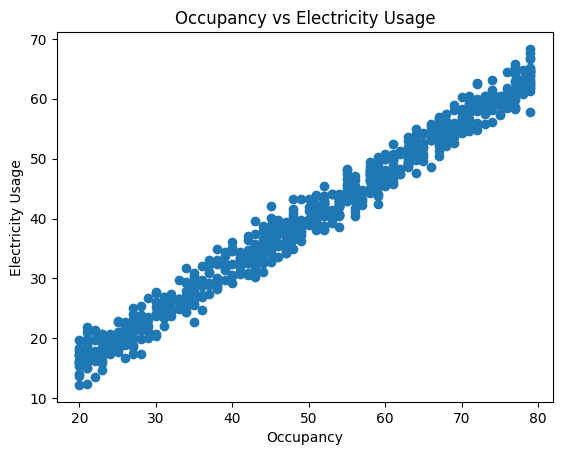

In [7]:
plt.scatter(data['occupancy'], data['electricity_usage'])
plt.xlabel("Occupancy")
plt.ylabel("Electricity Usage")
plt.title("Occupancy vs Electricity Usage")
plt.show()

In [8]:
train = data[:600]
test = data[600:]

train_exog = train['occupancy']
test_exog = test['occupancy']

In [10]:
model = SARIMAX(train['electricity_usage'],
                exog=train_exog,
                order=(1,1,1),
                seasonal_order=(0,0,0,0))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      electricity_usage   No. Observations:                  600
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1255.517
Date:                Fri, 20 Feb 2026   AIC                           2519.034
Time:                        05:27:53   BIC                           2536.615
Sample:                    01-01-2025   HQIC                          2525.879
                         - 01-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
occupancy      0.8018      0.004    179.606      0.000       0.793       0.811
ar.L1          0.0212      0.041      0.513      0.608      -0.060       0.102
ma.L1         -0.9906      0.009   -111.595      0.0

In [11]:
forecast = model_fit.get_forecast(steps=len(test),
                                  exog=test_exog)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

In [12]:
rmse = np.sqrt(mean_squared_error(test['electricity_usage'], forecast_mean))
mae = mean_absolute_error(test['electricity_usage'], forecast_mean)
r2 = r2_score(test['electricity_usage'], forecast_mean)

mape = np.mean(np.abs((test['electricity_usage'] - forecast_mean) /
                       test['electricity_usage'])) * 100

accuracy = 100 - mape

print("Model Performance Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Accuracy (%):", accuracy)

Model Performance Metrics:
RMSE: 1.9323354012970646
MAE: 1.5164242547565912
R2 Score: 0.9795404011558493
Accuracy (%): 95.58207003861966


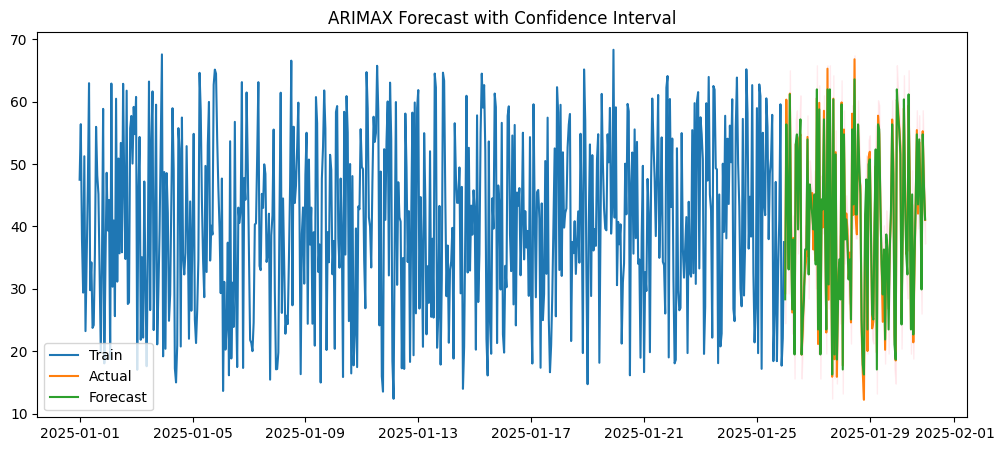

In [13]:

plt.figure(figsize=(12,5))
plt.plot(train.index, train['electricity_usage'], label="Train")
plt.plot(test.index, test['electricity_usage'], label="Actual")
plt.plot(test.index, forecast_mean, label="Forecast")

plt.fill_between(test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("ARIMAX Forecast with Confidence Interval")
plt.show()